<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Handling_Missing_Numerical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mean Median Imputation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('titanic_toy.csv')

In [7]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [9]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [13]:
X_train.isnull().mean()

,0
Age,0.196629
Fare,0.050562
Family,0.000000


In [14]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [15]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [17]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
352,15.0,7.2292,2,15.0,15.000000,7.2292,7.2292
413,NaN,0.0000,0,28.0,29.498846,0.0000,0.0000
6,54.0,51.8625,0,54.0,54.000000,51.8625,51.8625
435,14.0,120.0000,3,14.0,14.000000,120.0000,120.0000
722,34.0,13.0000,0,34.0,34.000000,13.0000,13.0000


In [18]:
print('Orignial Age Variable Variance : ' , X_train['Age'].var())
print('Imputed Age Variable Variance : ' , X_train['Age_mean'].var())
print('Age Variance after median imputation : ' , X_train['Age_median'].var() )


print('Orignial Fare Variable Variance : ' , X_train['Fare'].var())
print('Imputed Fare Variable Variance : ' , X_train['Fare_mean'].var())
print('Fare Variance after median imputation : ' , X_train['Fare_median'].var() )
#

Orignial Age Variable Variance :  210.2517072477438
Imputed Age Variable Variance :  168.8519336687225
Age Variance after median imputation :  169.20731007048096
Orignial Fare Variable Variance :  2761.031434948639
Imputed Fare Variable Variance :  2621.2323749512393
Fare Variance after median imputation :  2637.01248167777


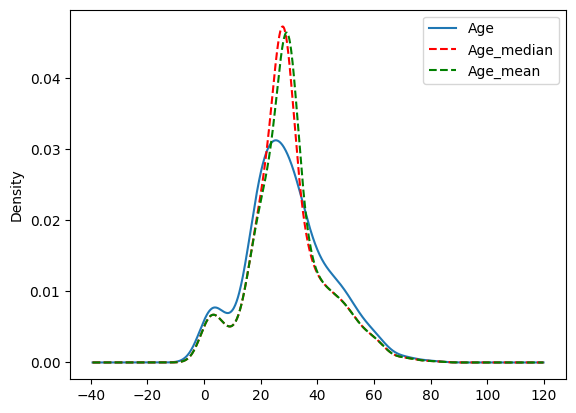

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

#orginal variable distribution
X_train['Age'].plot(kind = 'kde',ax=ax)

#variable imputed with median
X_train['Age_median'].plot(kind='kde',ax=ax,linestyle='--',color='red')

#variable imputed with mean
X_train['Age_mean'].plot(kind='kde',ax=ax,linestyle='--',color='green')

#add legends
lines , lables = ax.get_legend_handles_labels()
ax.legend(lines,lables,loc='best')

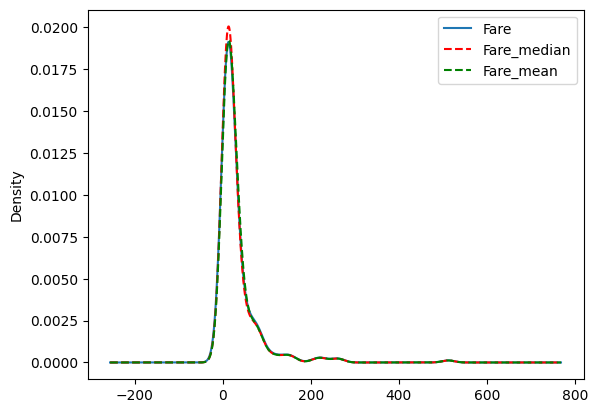

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind = 'kde',ax=ax)
X_train['Fare_median'].plot(kind = 'kde',ax=ax,linestyle='--',color='red')
X_train['Fare_mean'].plot(kind = 'kde',ax=ax,linestyle='--',color='green')


lines,labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc = 'best')

In [21]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [22]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

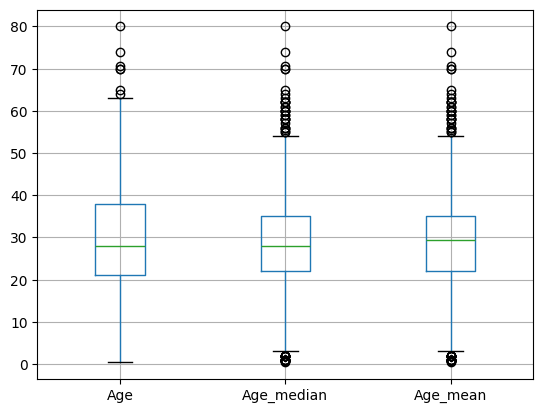

In [23]:
X_train[['Age' , 'Age_median' , 'Age_mean']].boxplot()

<Axes: >

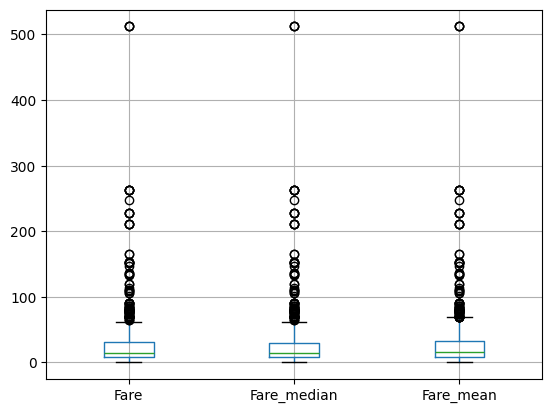

In [24]:
X_train[['Fare' , 'Fare_median' , 'Fare_mean']].boxplot()

###Using Sklearn

In [25]:
X_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [27]:
trf = ColumnTransformer([('imputer1' , imputer1,['Age']) , ('imputer2' , imputer2 , ['Fare'])] , remainder = 'passthrough')

In [28]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(), ['Age']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [29]:
trf.named_transformers_['imputer1'].statistics_

array([29.49884615])

In [30]:
trf.named_transformers_['imputer2'].statistics_

array([14.4])